
TABELA UNIFICADA


In [6]:
import pandas as pd
from functools import reduce

print("A carregar estritamente os ficheiros TRATADOS...")

# 1. Forçar a leitura APENAS dos arquivos que já passaram pelo tratamento
df_sinistros = pd.read_csv('../bases/tabelas_tratadas/Atendimento_Sinistros_Tratado_Final.csv')
df_mkt       = pd.read_csv('../bases/tabelas_tratadas/Engajamento_Marketing_Tratado_Final.csv')
df_contratos = pd.read_csv('../bases/tabelas_tratadas/contratos_apolices_tratada.csv') 
df_cadastro  = pd.read_csv('../bases/tabelas_tratadas/cadastro_clientes_tratada.csv')
df_churn     = pd.read_csv('../bases/tabelas_brutas/churn_.csv')

dfs = [df_contratos, df_cadastro, df_sinistros, df_mkt, df_churn]

# 2. Garantir o alinhamento das chaves
print("A alinhar os IDs...")
for df in dfs:
    col_id = df.columns[0]
    df.rename(columns={col_id: 'cod_individuo'}, inplace=True)
    df['cod_individuo'] = df['cod_individuo'].astype(str).str.replace('IND-', '', regex=False).str.replace('.0', '', regex=False).str.strip()

# 3. Cruzar as tabelas limpas
print("A realizar o cruzamento final...")
df_final_tratada = reduce(lambda left, right: pd.merge(left, right, on='cod_individuo', how='inner'), dfs)

# 4. Exportar imediatamente para não haver confusão na memória
nome_arquivo = '../bases/tabelas_unificadas/Base_Unificada_Tratada.csv'
df_final_tratada.to_csv(nome_arquivo, index=False)

print(f"\nSUCESSO ABSOLUTO! A base foi cruzada e guardada como: {nome_arquivo}")
print(f"Linhas: {len(df_final_tratada)} | Colunas: {df_final_tratada.shape[1]}")

display(df_final_tratada.head())

A carregar estritamente os ficheiros TRATADOS...
A alinhar os IDs...
A realizar o cruzamento final...

SUCESSO ABSOLUTO! A base foi cruzada e guardada como: ../bases/tabelas_unificadas/Base_Unificada_Tratada.csv
Linhas: 81881 | Colunas: 81


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,veiculo_Van,regiao_Centro,regiao_Centro-Oeste,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned
0,221300904264,2.0,2316.72,2339.0,01/05/2020,5.0,201525.43,2446.83,1.0,0.066,...,0,0,1,0,0,0,0,0,0,0
1,221300318278,3.0,NaN,1648.0,26/11/2021,1.0,NaN,NaN,1.0,0.103,...,0,0,0,0,1,0,0,0,0,0
2,221302854940,NaN,1033.15,187.0,26/11/2025,5.0,196256.43,951.09,1.0,0.050,...,0,0,1,0,0,0,0,0,0,0
3,221300164895,1.0,873.83,1085.0,12/06/2023,4.0,150726.78,840.06,1.0,0.034,...,0,0,1,0,0,0,0,0,0,0
4,221302543275,1.0,1084.81,5315.0,12/11/2011,4.0,208885.94,1109.27,1.0,0.018,...,0,0,0,0,0,0,0,0,1,0


TABELA OUTER

In [7]:
import pandas as pd
from functools import reduce

print("A carregar estritamente os ficheiros TRATADOS...")

df_sinistros = pd.read_csv('../bases/tabelas_tratadas/Atendimento_Sinistros_Tratado_Final.csv')
df_mkt       = pd.read_csv('../bases/tabelas_tratadas/Engajamento_Marketing_Tratado_Final.csv')
df_contratos = pd.read_csv('../bases/tabelas_tratadas/contratos_apolices_tratada.csv') 
df_cadastro  = pd.read_csv('../bases/tabelas_tratadas/cadastro_clientes_tratada.csv')
df_churn     = pd.read_csv('../bases/tabelas_brutas/churn_.csv')

dfs = [df_contratos, df_cadastro, df_sinistros, df_mkt, df_churn]

# Alinhar IDs
print("A alinhar os IDs...")
for df in dfs:
    col_id = df.columns[0]
    df.rename(columns={col_id: 'cod_individuo'}, inplace=True)
    df['cod_individuo'] = (
        df['cod_individuo']
        .astype(str)
        .str.replace('IND-', '', regex=False)
        .str.replace('.0', '', regex=False)
        .str.strip()
    )

# 🔥 OUTER MERGE (união completa)
print("A realizar o cruzamento completo (outer merge)...")
df_final_tratada = reduce(
    lambda left, right: pd.merge(left, right, on='cod_individuo', how='outer'),
    dfs
)

# Exportar
nome_arquivo = '../bases/tabelas_unificadas/Base_Unificada_Outer.csv'
df_final_tratada.to_csv(nome_arquivo, index=False)

print(f"\nSUCESSO! Base unificada como: {nome_arquivo}")
print(f"Linhas: {len(df_final_tratada)} | Colunas: {df_final_tratada.shape[1]}")

display(df_final_tratada.head())

A carregar estritamente os ficheiros TRATADOS...
A alinhar os IDs...
A realizar o cruzamento completo (outer merge)...

SUCESSO! Base unificada como: ../bases/tabelas_unificadas/Base_Unificada_Outer.csv
Linhas: 100000 | Colunas: 81


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,veiculo_Van,regiao_Centro,regiao_Centro-Oeste,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned
0,221300000040,2.0,1077.82,2165.0,27/06/2020,2.0,161891.00,1083.49,1.0,0.049,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,221300000051,1.0,1342.00,4309.0,14/08/2014,4.0,131680.75,753.93,1.0,0.054,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,221300000085,3.0,1542.00,1550.0,04/03/2022,1.0,81434.11,1732.02,1.0,0.081,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,221300000119,2.0,1189.46,1651.0,23/11/2021,NaN,121370.92,657.88,1.0,0.033,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,221300000218,NaN,620.10,1902.0,17/03/2021,2.0,153965.39,662.30,1.0,0.035,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0




GRÁFICOS



Analisando o impacto total (incluindo novas categorias) no Churn...



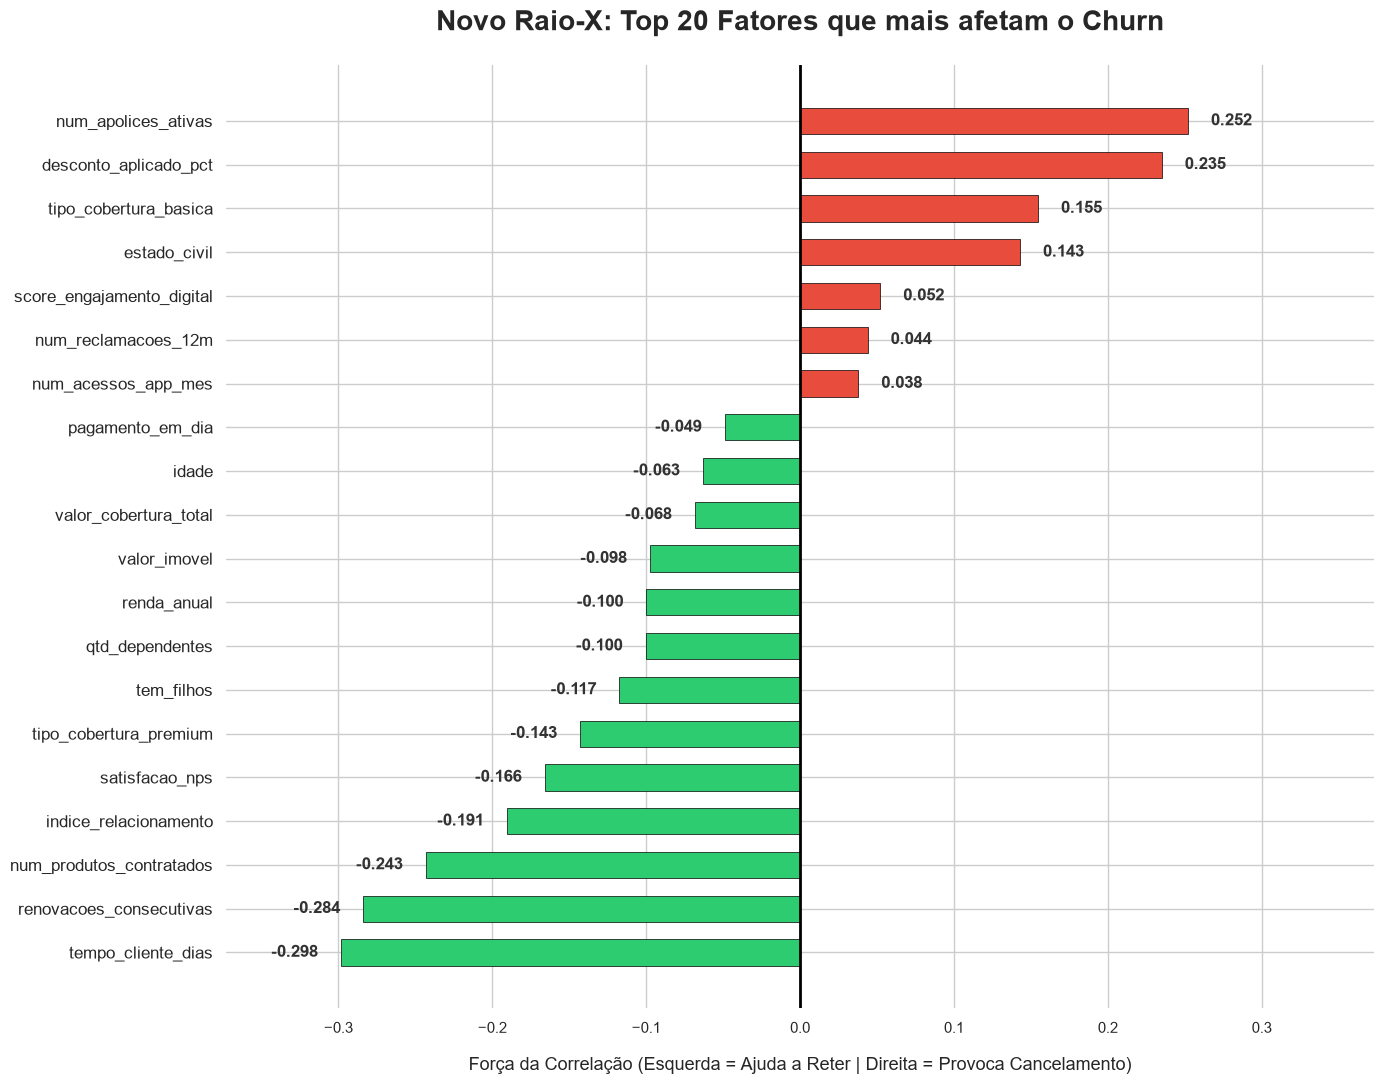

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Analisando o impacto total (incluindo novas categorias) no Churn...\n")

# 1. Filtra apenas as colunas numéricas (o que inclui nossos novos binários 0 e 1)
# Assumindo que a sua tabela final atualizada se chame df_final_tratada
colunas_numericas = df_final_tratada.select_dtypes(include=['int32', 'int64', 'float64']).columns

# 2. Calcula a correlação de todas as variáveis com o 'churned'
corr_total = df_final_tratada[colunas_numericas].corr()[['churned']].drop('churned')

# 3. Puxa o Top 20 de MAIOR IMPACTO absoluto (seja para reter ou para cancelar)
corr_total['impacto_absoluto'] = corr_total['churned'].abs()
top_20_impacto = corr_total.sort_values(by='impacto_absoluto', ascending=False).head(20)

# Ordena pelo valor real da correlação para o gráfico ficar dividido entre vermelho e verde
top_20_plot = top_20_impacto.sort_values(by='churned', ascending=True)

# 4. Definição de cores: Vermelho (causa Churn > 0) e Verde (Retém < 0)
cores = ['#2ecc71' if x < 0 else '#e74c3c' for x in top_20_plot['churned']]

# 5. Configuração do gráfico
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 11))

barras = ax.barh(
    top_20_plot.index, 
    top_20_plot['churned'], 
    color=cores, 
    height=0.6, 
    edgecolor='black', 
    linewidth=0.5
)

# 6. Adiciona os valores exatos nas pontas das barras
for i, v in enumerate(top_20_plot['churned']):
    deslocamento = 0.015 if v > 0 else -0.015
    alinhamento = 'left' if v > 0 else 'right'
    ax.text(v + deslocamento, i, f"{v:.3f}", 
            va='center', ha=alinhamento, 
            fontsize=12, fontweight='bold', color='#333333')

# 7. Títulos e rótulos
ax.set_title('Novo Raio-X: Top 20 Fatores que mais afetam o Churn', fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Força da Correlação (Esquerda = Ajuda a Reter | Direita = Provoca Cancelamento)', fontsize=13, labelpad=15)
ax.set_ylabel('', fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Linha Zero Central e limpeza das bordas
ax.axvline(0, color='black', linewidth=2, linestyle='-')
sns.despine(left=True, bottom=True, top=True, right=True)

# Expande o eixo X para os números não cortarem
lim_max = max(abs(top_20_plot['churned'].min()), abs(top_20_plot['churned'].max())) * 1.25
ax.set_xlim(-lim_max, lim_max)

plt.tight_layout()
plt.show()

Impacto das categorias (Binárias) no Churn:


,churned
veiculo_Moto,0.006546
segmento_Prata,0.005120
canal_aquisicao_Digital,0.004384
veiculo_Pickup,0.003904
regiao_NaN,0.002319
canal_Nao Informado,0.002280
canal_aquisicao_Agente,0.002019
regiao_Sudeste,0.001747
regiao_Centro,0.001179
canal_WhatsApp,0.000824


<Axes: title={'center': 'Correlação das Categorias com Churn'}>

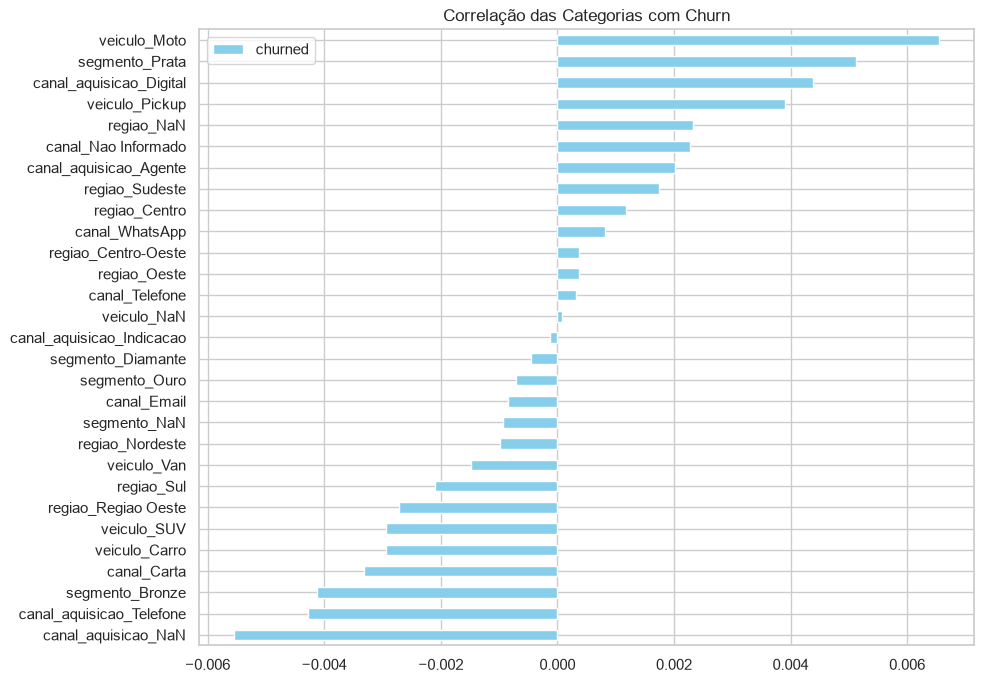

In [9]:
# 1. Lista as colunas que criamos (o Python nos ajuda a identificar pelo nome)
colunas_de_interesse = [col for col in df_final_tratada.columns if any(x in col for x in ['veiculo_', 'regiao_', 'segmento_', 'canal_'])]

# 2. Calcula a correlação apenas dessas colunas com o 'churned'
analise_especifica = df_final_tratada[colunas_de_interesse + ['churned']].corr()[['churned']].drop('churned')

# 3. Mostra o resultado ordenado da maior correlação positiva para a negativa
print("Impacto das categorias (Binárias) no Churn:")
display(analise_especifica.sort_values(by='churned', ascending=False))

# 4. Se quiser ver os valores isolados num gráfico rápido
analise_especifica.sort_values(by='churned').plot(kind='barh', figsize=(10, 8), color='skyblue', title='Correlação das Categorias com Churn')


Análise Exploratória - Gráfico I


A gerar o painel de Analise Exploratoria...


C:\Users\grace\AppData\Local\Temp\ipykernel_10752\2834467658.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final_eda, x="churned", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\2834467658.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="tipo_veiculo", y="churned", ax=axes[1], palette="magma", errorbar=None)


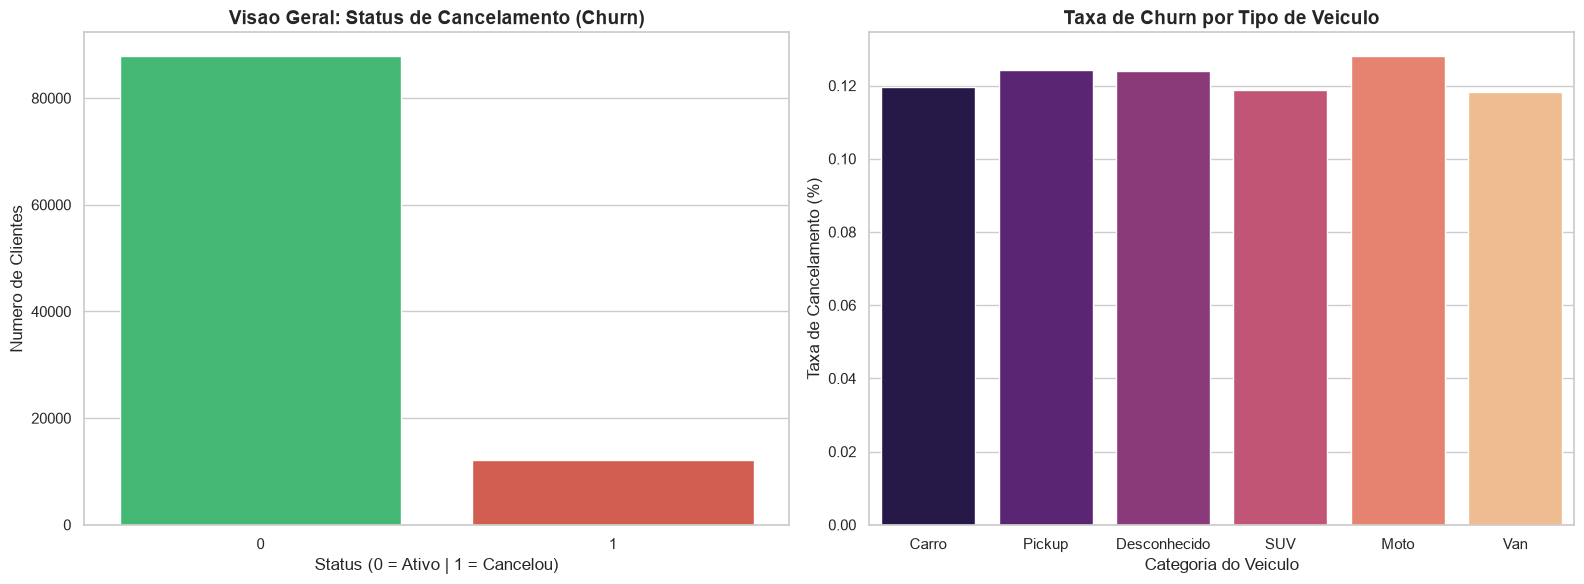

Taxa Global de Churn da Seguradora: 12.09%


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_final_tratada foi gerado pela celula de outer merge acima
df_final_eda = df_final_tratada

print("A gerar o painel de Analise Exploratoria...")

sns.set_theme(style="whitegrid")

# Reconstroi tipo_veiculo a partir das colunas binarias (one-hot encoding do tratamento)
veiculo_cols = [col for col in df_final_eda.columns if col.startswith("veiculo_") and col != "veiculo_NaN"]
df_plot = df_final_eda.copy()
df_plot["tipo_veiculo"] = df_plot[veiculo_cols].fillna(0).idxmax(axis=1).str.replace("veiculo_", "", regex=False)
mask_sem = df_plot[veiculo_cols].fillna(0).max(axis=1) == 0
df_plot.loc[mask_sem, "tipo_veiculo"] = "Desconhecido"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# GRAFICO 1: O Balanceamento do Churn
# ==========================================
sns.countplot(data=df_final_eda, x="churned", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Visao Geral: Status de Cancelamento (Churn)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Status (0 = Ativo | 1 = Cancelou)", fontsize=12)
axes[0].set_ylabel("Numero de Clientes", fontsize=12)

# ==========================================
# GRAFICO 2: Tipo de Veiculo vs. Churn
# ==========================================
sns.barplot(data=df_plot, x="tipo_veiculo", y="churned", ax=axes[1], palette="magma", errorbar=None)
axes[1].set_title("Taxa de Churn por Tipo de Veiculo", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Categoria do Veiculo", fontsize=12)
axes[1].set_ylabel("Taxa de Cancelamento (%)", fontsize=12)

plt.tight_layout()
plt.show()

taxa_global = df_final_eda["churned"].mean() * 100
print(f"Taxa Global de Churn da Seguradora: {taxa_global:.2f}%")



Tipo de Vecículo não impacta tanto na taxa de Churn


A gerar gráficos de barras claros e com valores exatos...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\841388694.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final_eda, x='churned', y='satisfacao_nps', ax=axes[0], palette=cores, errorbar=None)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\841388694.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\841388694.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final_eda, x='churned', y='num_ligacoes_suporte_12m', ax=axes[1],

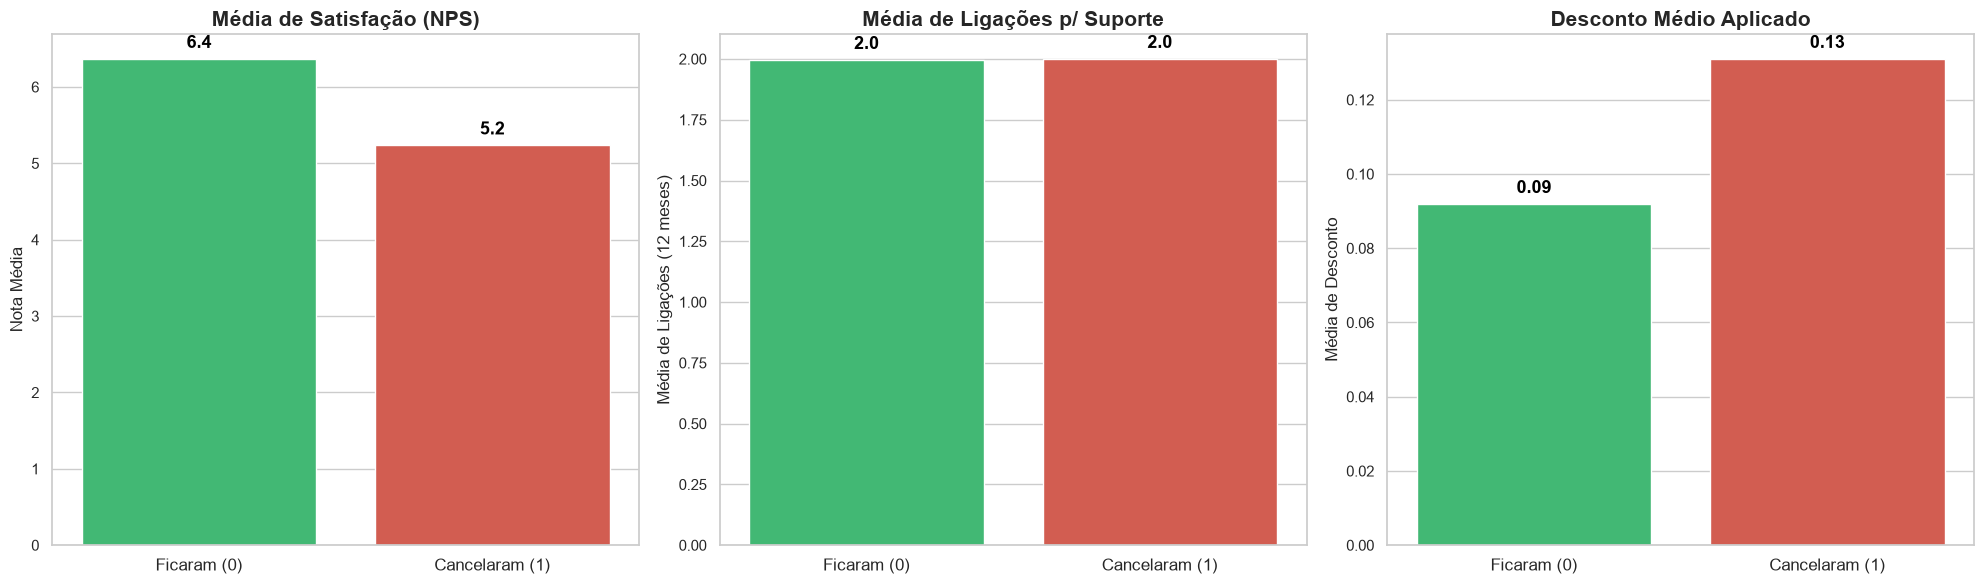

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("A gerar gráficos de barras claros e com valores exatos...\n")

sns.set_theme(style="whitegrid")
# Criamos o painel para as 3 variáveis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cores = ['#2ecc71', '#e74c3c'] # Verde para Ativos, Vermelho para Cancelados

# Função auxiliar para colocar os números em cima das barras
def adicionar_rotulos(ax, formato="{:.2f}"):
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0: # Para evitar colocar números em barras vazias
            ax.annotate(formato.format(altura), 
                        (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='bottom', 
                        fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                        textcoords='offset points')

# =======================================================
# 1. Média de Satisfação (NPS)
# =======================================================
sns.barplot(data=df_final_eda, x='churned', y='satisfacao_nps', ax=axes[0], palette=cores, errorbar=None)
axes[0].set_title('Média de Satisfação (NPS)', fontsize=15, fontweight='bold')
axes[0].set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Nota Média', fontsize=12)
adicionar_rotulos(axes[0], "{:.1f}")

# =======================================================
# 2. Média de Ligações para o Suporte
# =======================================================
sns.barplot(data=df_final_eda, x='churned', y='num_ligacoes_suporte_12m', ax=axes[1], palette=cores, errorbar=None)
axes[1].set_title('Média de Ligações p/ Suporte', fontsize=15, fontweight='bold')
axes[1].set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Média de Ligações (12 meses)', fontsize=12)
adicionar_rotulos(axes[1], "{:.1f}")

# =======================================================
# 3. Média de Desconto Aplicado
# =======================================================
sns.barplot(data=df_final_eda, x='churned', y='desconto_aplicado_pct', ax=axes[2], palette=cores, errorbar=None)
axes[2].set_title('Desconto Médio Aplicado', fontsize=15, fontweight='bold')
axes[2].set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
axes[2].set_xlabel('')
axes[2].set_ylabel('Média de Desconto', fontsize=12)
adicionar_rotulos(axes[2], "{:.2f}")

plt.tight_layout()
plt.show()


-Atrito no Suporte não impacta na taxa de Churn

-Desconto não está mantendo os clientes, então é a falta de qualidade em algum serviço mas do que o valor cobrado o problema


Analisando o impacto do Tempo de Resposta no Churn...



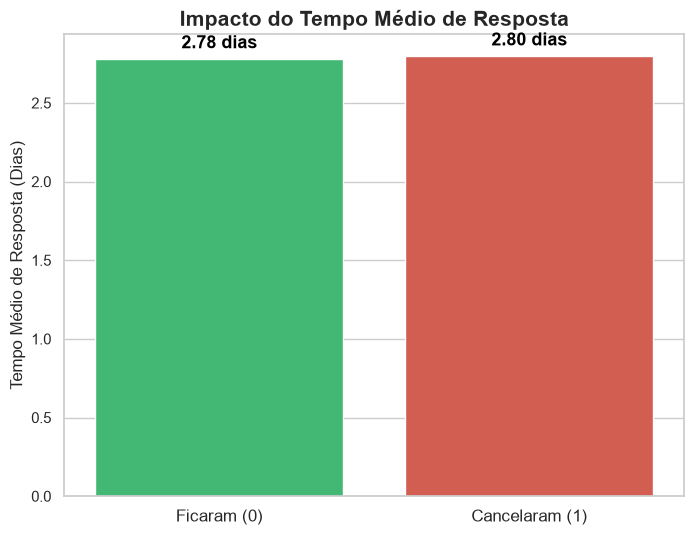

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analisando o impacto do Tempo de Resposta no Churn...\n")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=df_final_eda,
    x='churned',
    y='tempo_medio_resposta_dias',
    hue='churned',
    palette=['#2ecc71', '#e74c3c'],
    ax=ax,
    errorbar=None,
    legend=False
)

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        f"{altura:.2f} dias",
        (p.get_x() + p.get_width() / 2., altura),
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

ax.set_title('Impacto do Tempo Médio de Resposta', fontsize=15, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tempo Médio de Resposta (Dias)', fontsize=12)

plt.show()

Analisando o impacto da Renda Anual no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\997251001.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final_eda, x='churned', y='renda_anual', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\997251001.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)


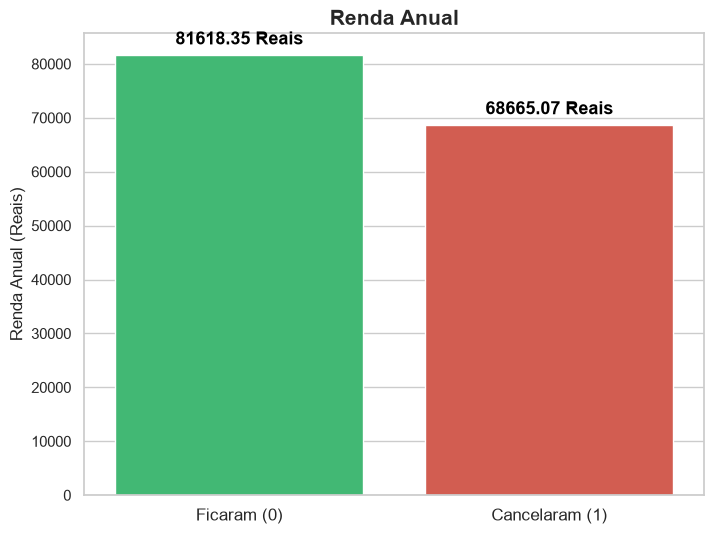

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analisando o impacto da Renda Anual no Churn...\n")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de barras: Renda Anual (reais) vs Churn
sns.barplot(data=df_final_eda, x='churned', y='renda_anual', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)

# Adicionar os rótulos de valor no topo
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{altura:.2f} Reais", 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

ax.set_title('Renda Anual', fontsize=15, fontweight='bold')
ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Renda Anual (Reais)', fontsize=12)

plt.show()

Renda anual é um fator considerável

A gerar o Raio-X focado exclusivamente no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3685877281.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


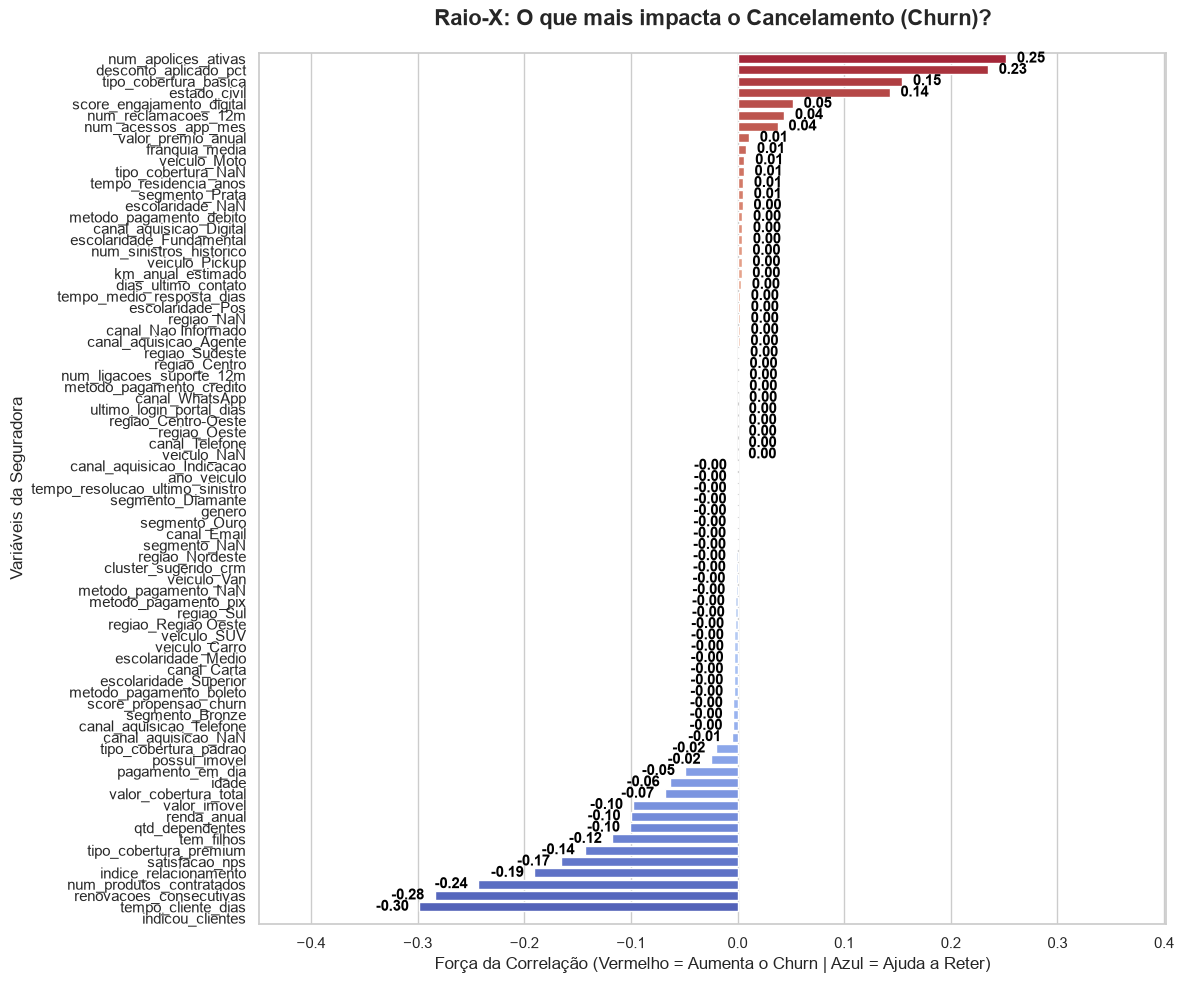

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("A gerar o Raio-X focado exclusivamente no Churn...\n")

# 1. Filtramos apenas as colunas matemáticas
df_numerico = df_final_eda.select_dtypes(include=[np.number])

# 2. Calculamos a correlação, mas isolamos APENAS a coluna 'churned'
correlacoes_churn = df_numerico.corr()[['churned']].sort_values(by='churned', ascending=False)

# Removemos a linha do próprio 'churned' (pois a correlação dele com ele mesmo é sempre 1.00)
correlacoes_churn = correlacoes_churn.drop('churned', errors='ignore')

# 3. Configuração do gráfico limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Criamos um gráfico de barras horizontais
grafico = sns.barplot(
    x=correlacoes_churn['churned'], 
    y=correlacoes_churn.index, 
    palette='coolwarm_r' # Vermelho para positivo (causa churn), Azul para negativo (evita churn)
)

# 4. Adicionamos os valores exatos no final de cada barra para facilitar a leitura
for index, value in enumerate(correlacoes_churn['churned']):
    posicao_x = value + 0.01 if value > 0 else value - 0.01
    alinhamento = 'left' if value > 0 else 'right'
    plt.text(posicao_x, index, f'{value:.2f}', va='center', ha=alinhamento, 
             fontsize=11, fontweight='bold', color='black')

# 5. Ajustes estéticos finais
plt.title('Raio-X: O que mais impacta o Cancelamento (Churn)?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Força da Correlação (Vermelho = Aumenta o Churn | Azul = Ajuda a Reter)', fontsize=12)
plt.ylabel('Variáveis da Seguradora', fontsize=12)

# Ajusta os limites para o texto não ficar cortado
plt.xlim(correlacoes_churn['churned'].min() - 0.15, correlacoes_churn['churned'].max() + 0.15)

plt.tight_layout()
plt.show()

Analisando o impacto do Numero de Apolices Ativas no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\4019066323.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final_eda, x='churned', y='num_apolices_ativas', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\4019066323.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)


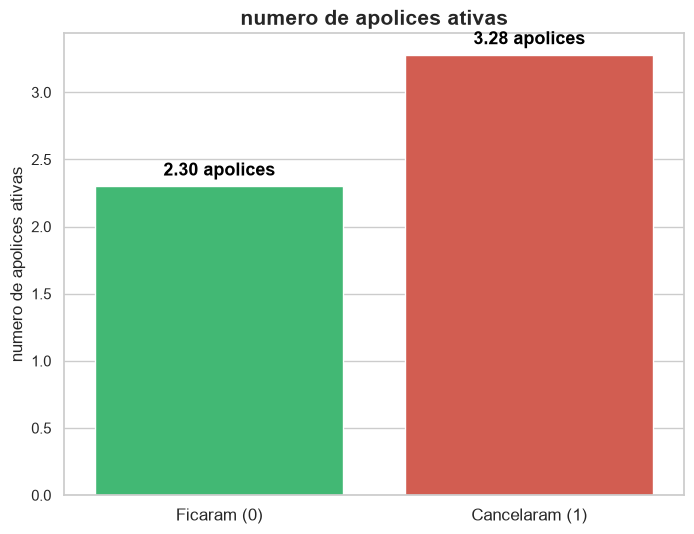

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analisando o impacto do Numero de Apolices Ativas no Churn...\n")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de barras: numero de apolices ativas vs Churn
sns.barplot(data=df_final_eda, x='churned', y='num_apolices_ativas', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)

# Adicionar os rótulos de valor no topo
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{altura:.2f} apolices", 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

ax.set_title('numero de apolices ativas', fontsize=15, fontweight='bold')
ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('numero de apolices ativas', fontsize=12)

plt.show()

Analisando o impacto do Numero de Apolices Ativas no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3479651170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3479651170.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Ficaram (0)", "Cancelaram (1)"], fontsize=12)


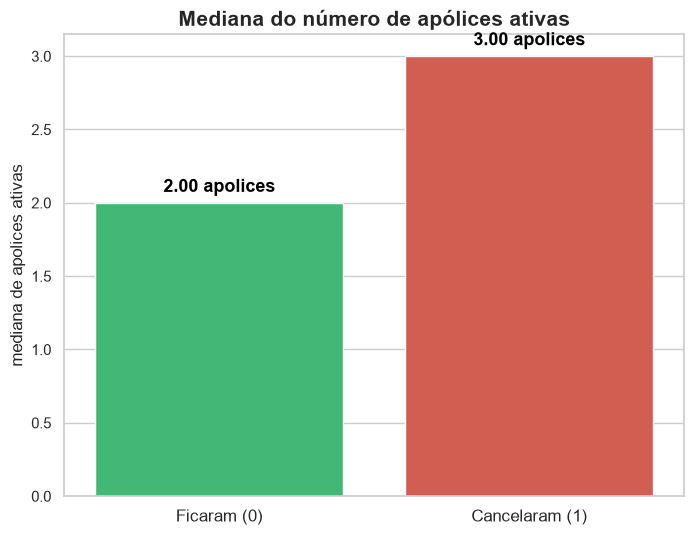

In [18]:
import matplotlib.pyplot as plt
import numpy as np  # IMPORTAÇÃO NECESSÁRIA
import seaborn as sns

print("Analisando o impacto do Numero de Apolices Ativas no Churn...\n")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Alteração aqui: adicionado o estimator=np.median
sns.barplot(
    data=df_final_eda,
    x="churned",
    y="num_apolices_ativas",
    ax=ax,
    palette=["#2ecc71", "#e74c3c"],
    errorbar=None,
    estimator=np.median,
)

# O restante do seu código de customização permanece igual...
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        f"{altura:.2f} apolices",
        (p.get_x() + p.get_width() / 2.0, altura),
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

ax.set_title("Mediana do número de apólices ativas", fontsize=15, fontweight="bold")
ax.set_xticklabels(["Ficaram (0)", "Cancelaram (1)"], fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("mediana de apolices ativas", fontsize=12)

plt.show()

Analisando o impacto do Número de Apólices por Tipo no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3152296091.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3152296091.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=11)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3152296091.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3152296091.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

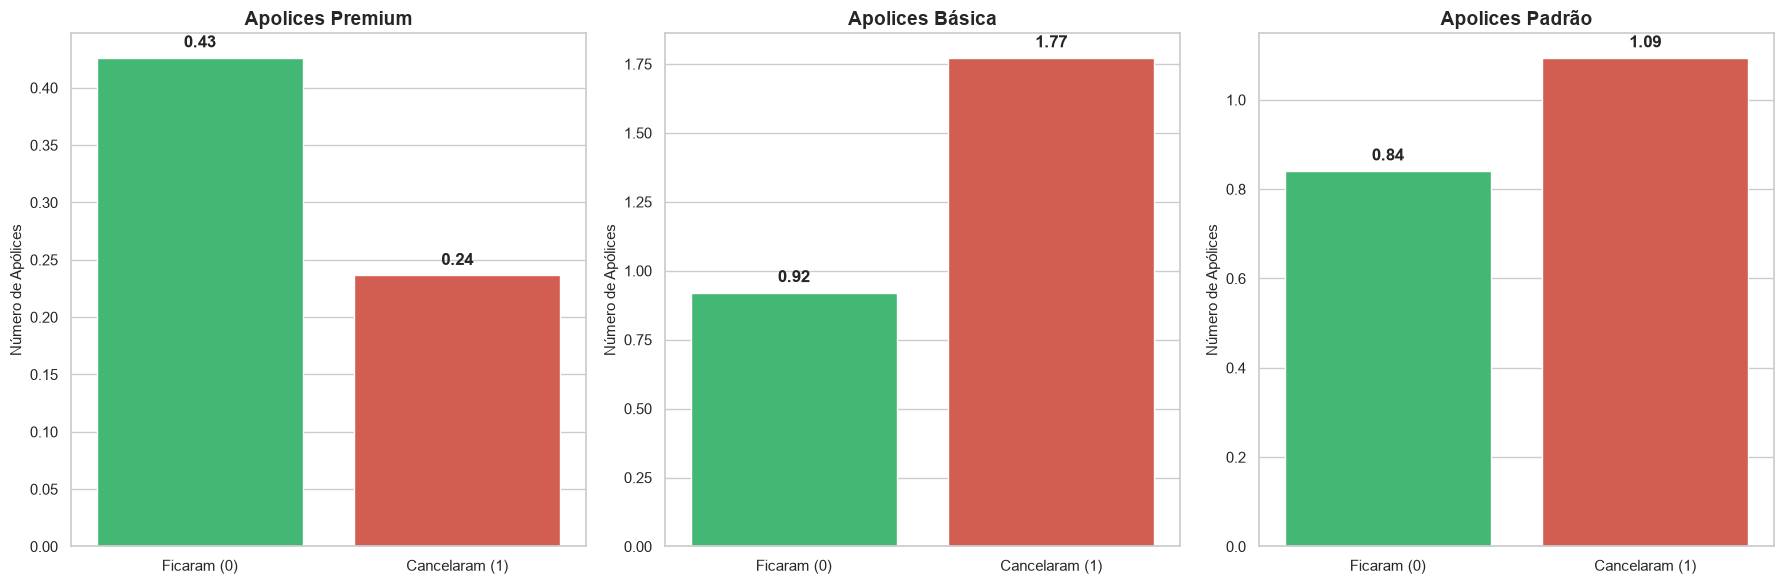

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../bases/tabelas_unificadas/Base_Unificada_Outer.csv')

print("Analisando o impacto do Número de Apólices por Tipo no Churn...\n")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colunas = [
    ('num_apolices_premium', 'Premium'),
    ('num_apolices_basica', 'Básica'),
    ('num_apolices_padrao', 'Padrão')
]

for ax, (col, titulo) in zip(axes, colunas):
    
    sns.barplot(
        data=df,
        x='churned',
        y=col,
        ax=ax,
        palette=['#2ecc71', '#e74c3c'],
        errorbar=None
    )

    # Labels nas barras
    for p in ax.patches:
        altura = p.get_height()
        ax.annotate(f"{altura:.2f}",
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold',
                    xytext=(0, 5),
                    textcoords='offset points')

    ax.set_title(f'Apolices {titulo}', fontsize=14, fontweight='bold')
    ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Número de Apólices', fontsize=11)

plt.tight_layout()
plt.show()

Analisando o impacto do tempo de clientes no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3535390947.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final_eda, x='churned', y='tempo_cliente_dias', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\3535390947.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)


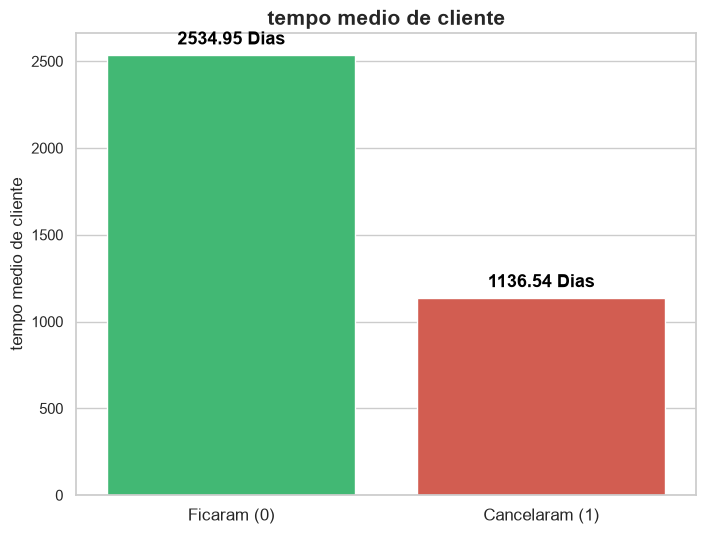

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analisando o impacto do tempo de clientes no Churn...\n")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de barras: tempo_cliente_dias vs Churn
sns.barplot(data=df_final_eda, x='churned', y='tempo_cliente_dias', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)

# Adicionar os rótulos de valor no topo
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{altura:.2f} Dias", 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

ax.set_title('tempo medio de cliente', fontsize=15, fontweight='bold')
ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('tempo medio de cliente', fontsize=12)

plt.show()

Analisando o impacto das Renovações Consecutivas no Churn...



C:\Users\grace\AppData\Local\Temp\ipykernel_10752\2258533774.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final_eda, x='churned', y='renovacoes_consecutivas', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)
C:\Users\grace\AppData\Local\Temp\ipykernel_10752\2258533774.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)


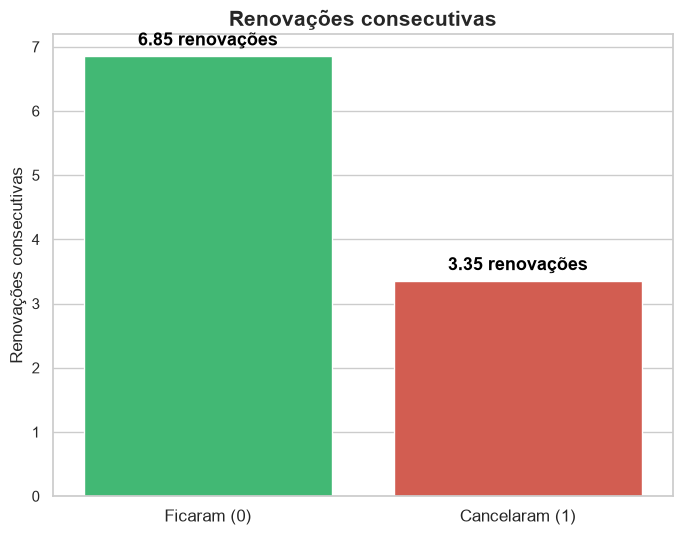

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Analisando o impacto das Renovações Consecutivas no Churn...\n")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Gráfico de barras: numero de apolices ativas vs Churn
sns.barplot(data=df_final_eda, x='churned', y='renovacoes_consecutivas', ax=ax, palette=['#2ecc71', '#e74c3c'], errorbar=None)

# Adicionar os rótulos de valor no topo
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{altura:.2f} renovações", 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

ax.set_title('Renovações consecutivas', fontsize=15, fontweight='bold')
ax.set_xticklabels(['Ficaram (0)', 'Cancelaram (1)'], fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Renovações consecutivas', fontsize=12)

plt.show()

CODIGO DE VARIOS GRAFICOS COMPARANDO DIVERSOSO PARAMETROS

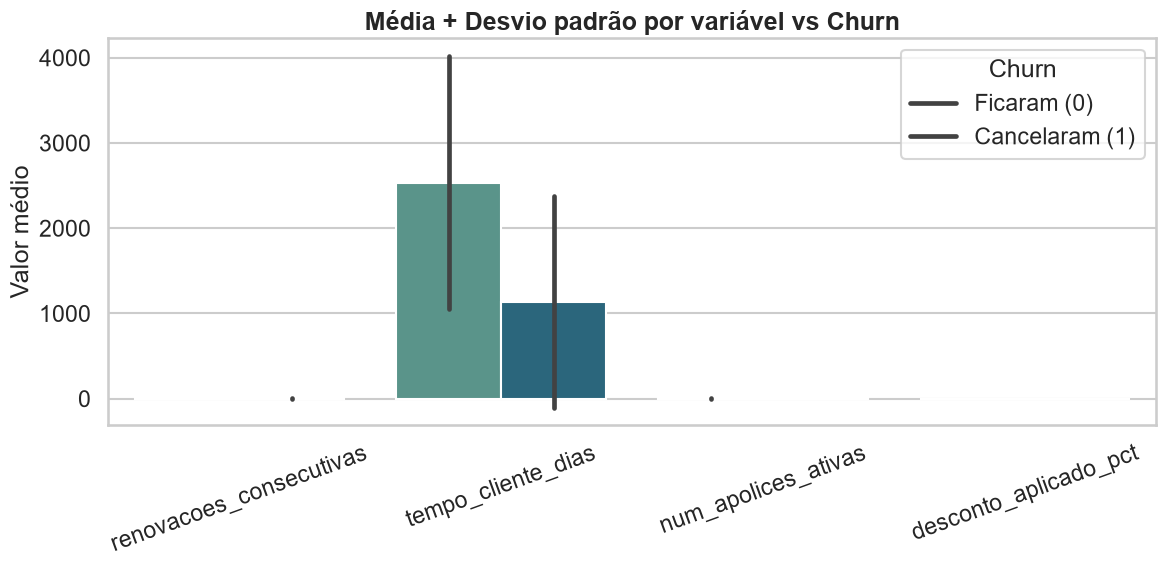

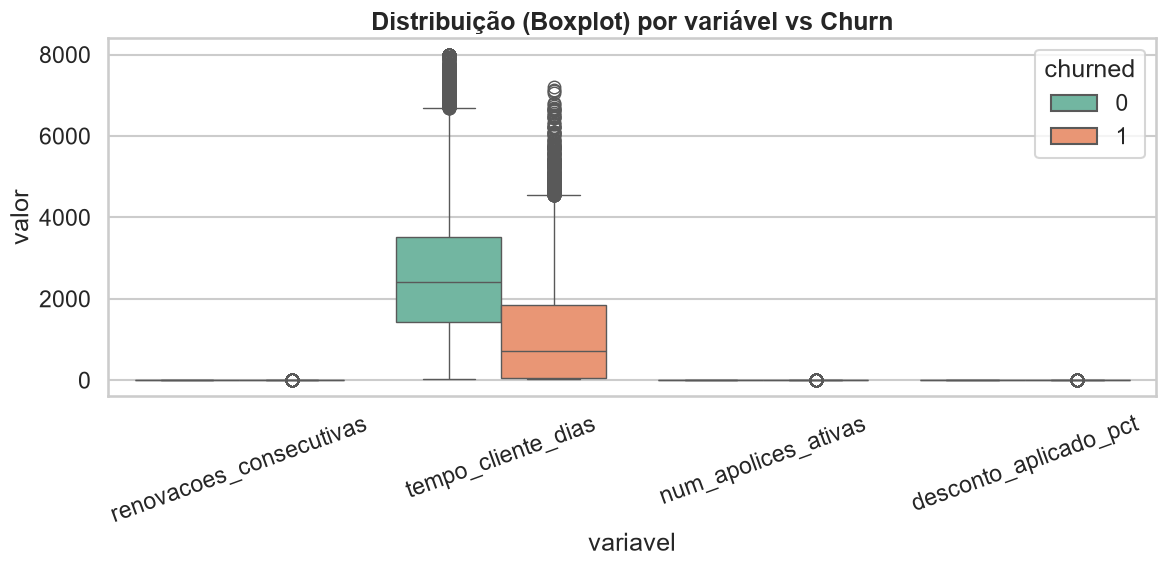

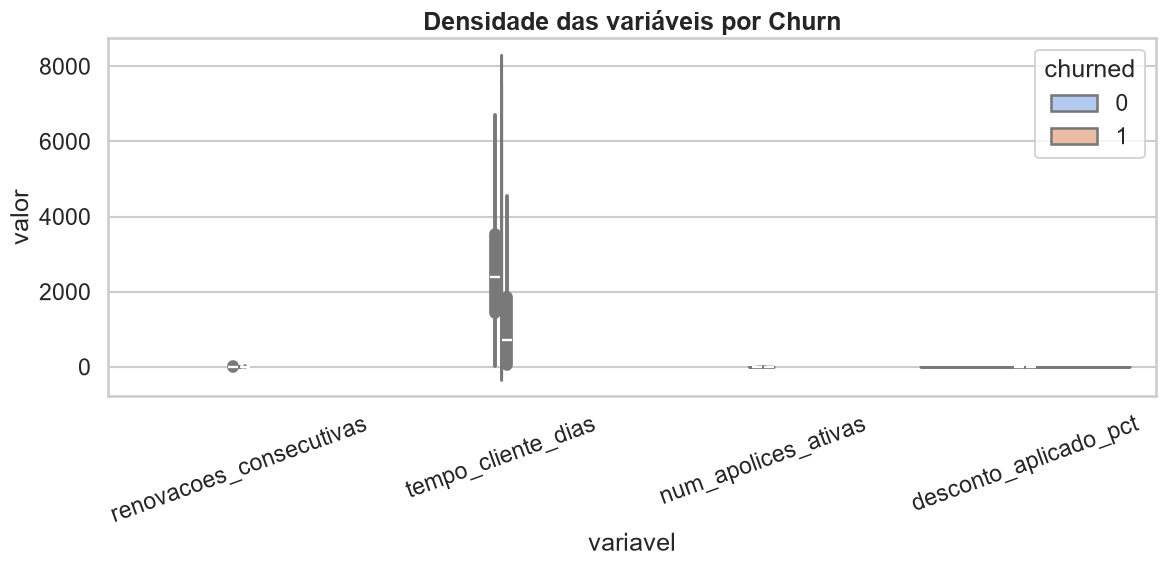

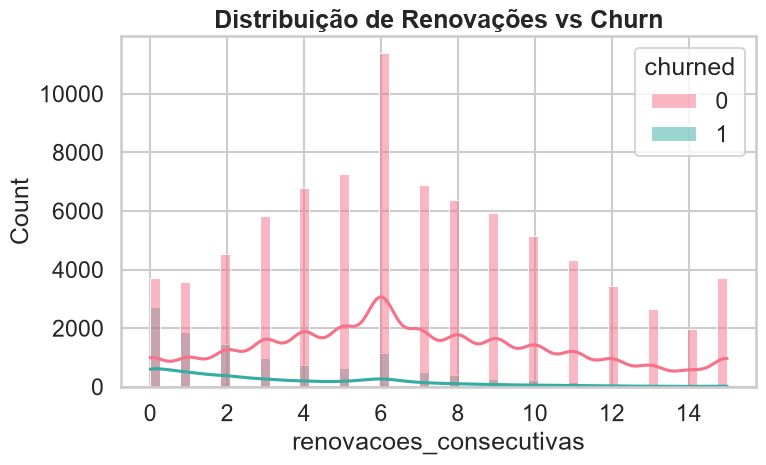

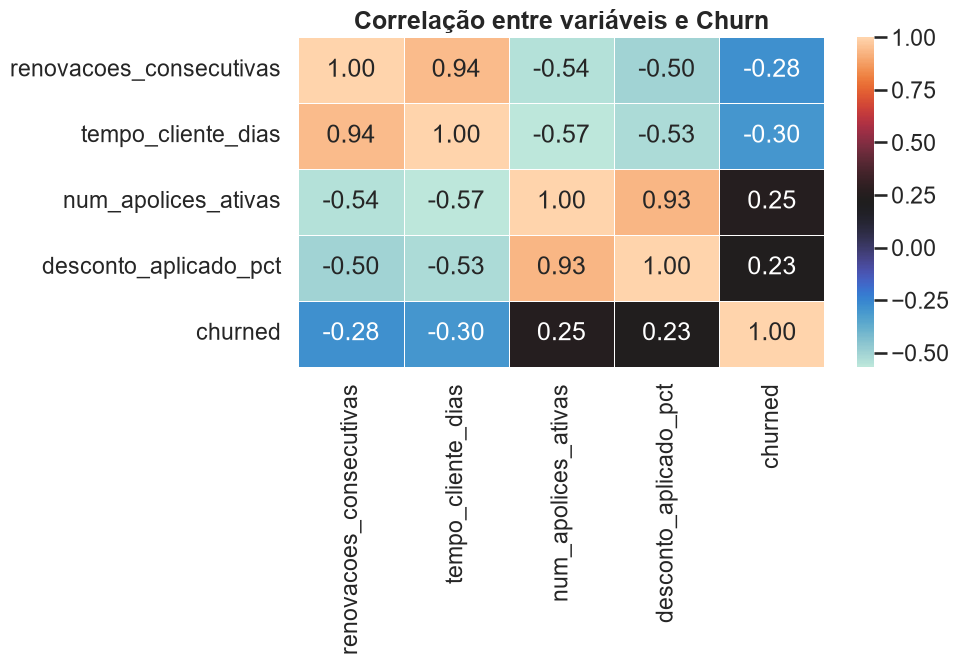

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# CONFIG VISUAL PROFISSIONAL
# =========================
sns.set_theme(style="whitegrid", context="talk")

# Variáveis que quer analisar
variaveis = [
    'renovacoes_consecutivas',
    'tempo_cliente_dias',
    'num_apolices_ativas',
    'desconto_aplicado_pct'
]

# =========================
# PREPARAÇÃO DOS DADOS
# =========================
df_melt = df_final_eda.melt(
    id_vars='churned',
    value_vars=variaveis,
    var_name='variavel',
    value_name='valor'
)

# =========================
# 1. BARPLOT (MÉDIA + DESVIO PADRÃO)
# =========================
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_melt,
    x='variavel',
    y='valor',
    hue='churned',
    errorbar='sd',
    palette='crest'
)

plt.title('Média + Desvio padrão por variável vs Churn', fontweight='bold')
plt.xticks(rotation=20)
plt.ylabel('Valor médio')
plt.xlabel('')
plt.legend(title='Churn', labels=['Ficaram (0)', 'Cancelaram (1)'])

plt.tight_layout()
plt.show()


# =========================
# 2. BOXPLOT (DISTRIBUIÇÃO REAL)
# =========================
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_melt,
    x='variavel',
    y='valor',
    hue='churned',
    palette='Set2'
)

plt.title('Distribuição (Boxplot) por variável vs Churn', fontweight='bold')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# =========================
# 3. VIOLIN (DENSIDADE)
# =========================
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_melt,
    x='variavel',
    y='valor',
    hue='churned',
    split=True,
    palette='coolwarm'
)

plt.title('Densidade das variáveis por Churn', fontweight='bold')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# =========================
# 4. HISTOGRAMA (EXEMPLO DE UMA VARIÁVEL)
# =========================
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_final_eda,
    x='renovacoes_consecutivas',
    hue='churned',
    kde=True,
    palette='husl'
)

plt.title('Distribuição de Renovações vs Churn', fontweight='bold')

plt.tight_layout()
plt.show()


# =========================
# 5. HEATMAP (CORRELAÇÃO)
# =========================
plt.figure(figsize=(10, 7))

corr = df_final_eda[variaveis + ['churned']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='icefire',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlação entre variáveis e Churn', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\grace\AppData\Local\Temp\ipykernel_10752\862886691.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


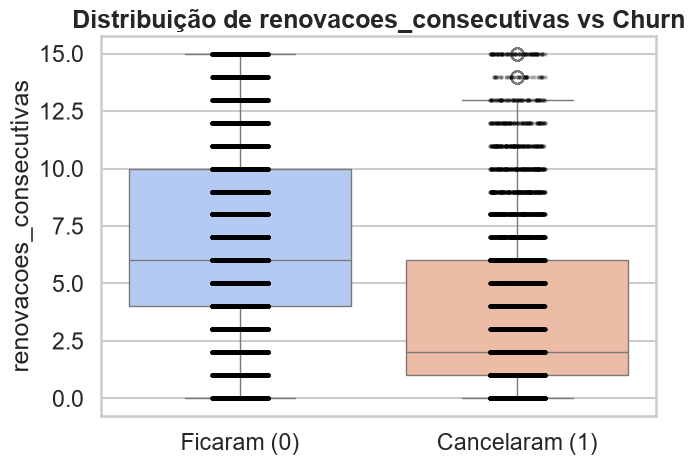

C:\Users\grace\AppData\Local\Temp\ipykernel_10752\862886691.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


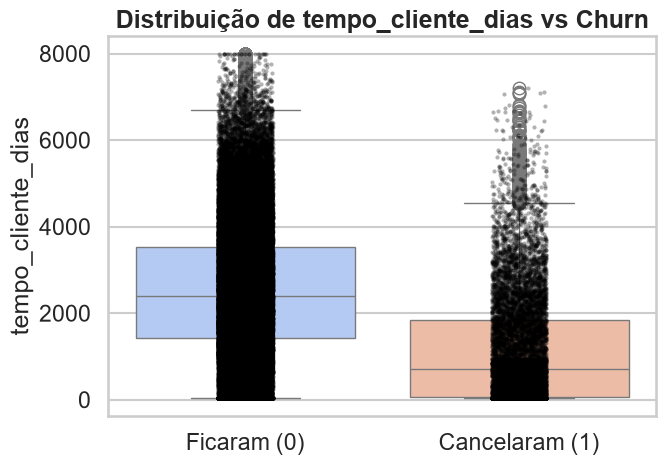

C:\Users\grace\AppData\Local\Temp\ipykernel_10752\862886691.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


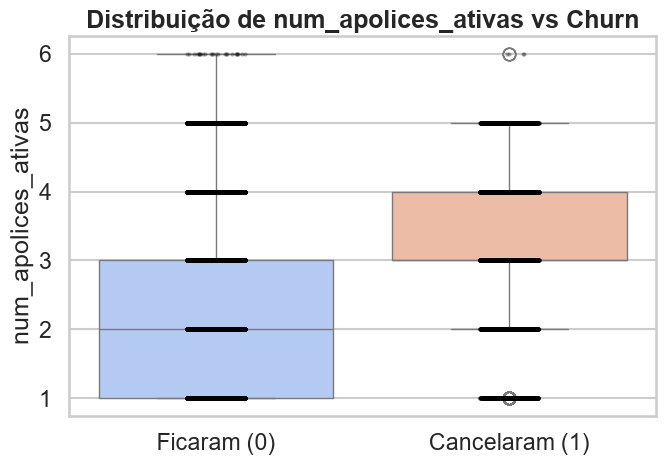

C:\Users\grace\AppData\Local\Temp\ipykernel_10752\862886691.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


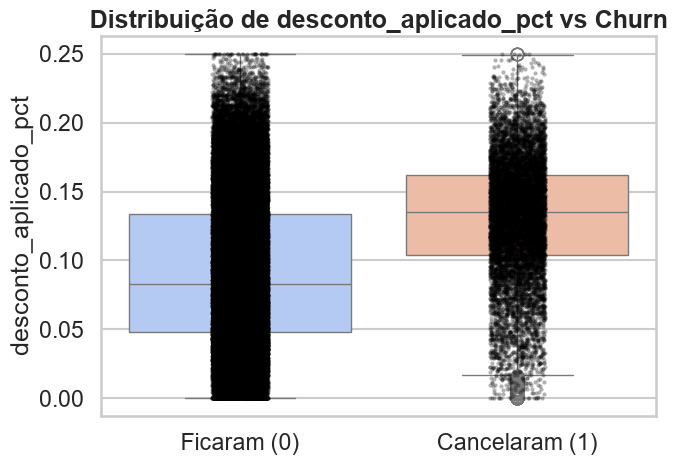

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

variaveis = [
    'renovacoes_consecutivas',
    'tempo_cliente_dias',
    'num_apolices_ativas',
    'desconto_aplicado_pct'
]

for var in variaveis:
    plt.figure(figsize=(7,5))
    
    sns.boxplot(
        data=df_final_eda,
        x='churned',
        y=var,
        palette='coolwarm'
    )

    # opcional: pontos individuais (muito bom pra ver distribuição real)
    sns.stripplot(
        data=df_final_eda,
        x='churned',
        y=var,
        color='black',
        alpha=0.3,
        size=3
    )

    plt.title(f'Distribuição de {var} vs Churn', fontweight='bold')
    plt.xticks([0,1], ['Ficaram (0)', 'Cancelaram (1)'])
    plt.xlabel('')
    plt.ylabel(var)

    plt.tight_layout()
    plt.show()

HEATMAP

Gerando o Gráfico Divergente para Apresentação Executiva...



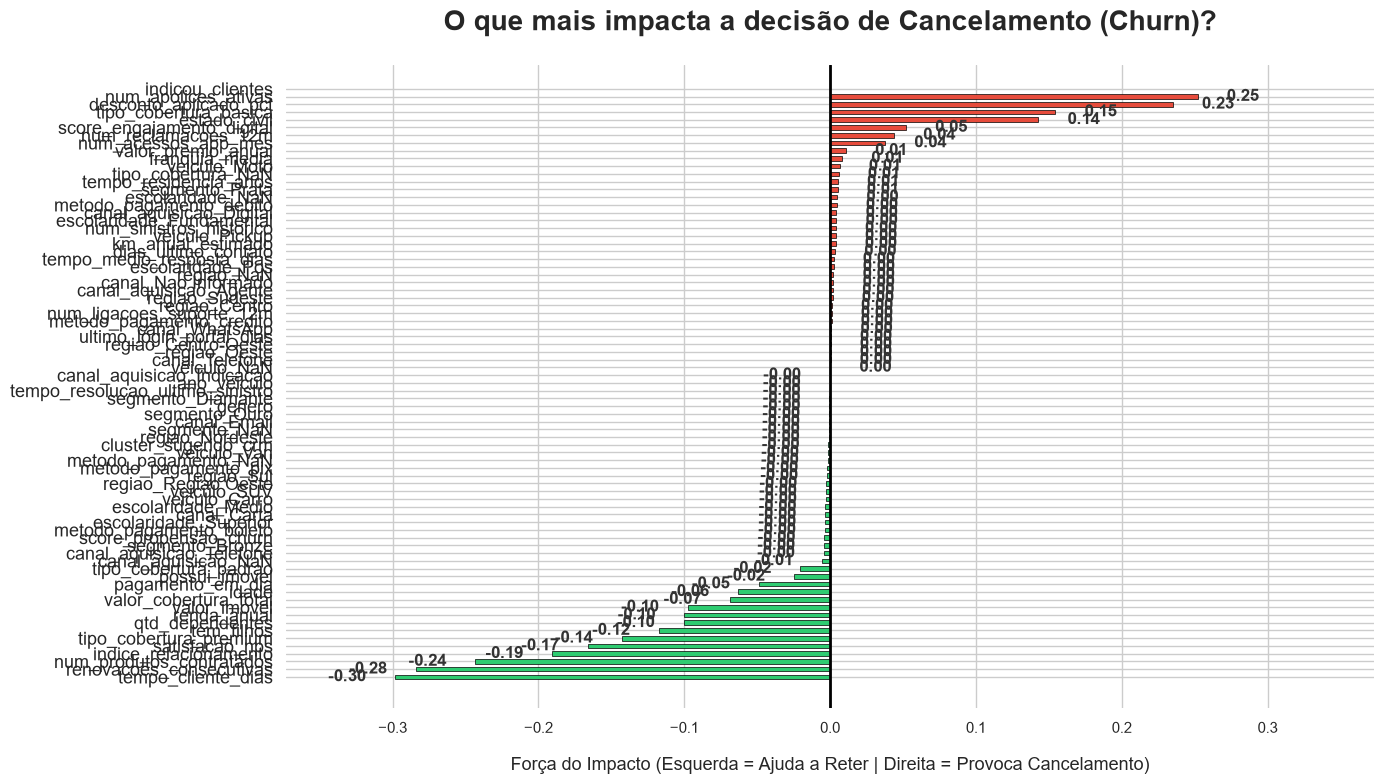

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Gerando o Gráfico Divergente para Apresentação Executiva...\n")

# 1. Filtramos as colunas numéricas e calculamos a correlação com o target
df_numerico = df_final_eda.select_dtypes(include=[np.number])
corr_target = df_numerico.corr()['churned'].drop('churned').sort_values()

# 2. Definimos cores: Verde para o que diminui o churn (negativo), Vermelho para o que aumenta (positivo)
cores = ['#2ecc71' if x < 0 else '#e74c3c' for x in corr_target]

# 3. Configuração do visual (formato de slide, horizontal e limpo)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# 4. Criamos as barras horizontais
ax.barh(corr_target.index, corr_target.values, color=cores, height=0.6, edgecolor='black', linewidth=0.5)

# 5. Adicionamos os valores exatos nas pontas das barras com espaçamento inteligente
for i, v in enumerate(corr_target.values):
    # Ajusta a posição do texto dependendo se a barra vai para a direita ou esquerda
    deslocamento = 0.02 if v > 0 else -0.02
    alinhamento = 'left' if v > 0 else 'right'
    ax.text(v + deslocamento, i, f"{v:.2f}", 
            va='center', ha=alinhamento, 
            fontsize=12, fontweight='bold', color='#333333')

# 6. Ajustes de estética para impressionar o cliente
ax.set_title('O que mais impacta a decisão de Cancelamento (Churn)?', fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Força do Impacto (Esquerda = Ajuda a Reter | Direita = Provoca Cancelamento)', fontsize=13, labelpad=15)
ax.set_ylabel('', fontsize=12) # Esconde o nome do eixo Y para ficar mais limpo
ax.tick_params(axis='y', labelsize=13) # Aumenta a fonte das categorias

# Adiciona a "Linha Zero" bem demarcada no meio
ax.axvline(0, color='black', linewidth=2, linestyle='-')

# Limpa as bordas do gráfico para um visual mais moderno
sns.despine(left=True, bottom=True, top=True, right=True)

# Expande o eixo X em 25% para garantir que os números não fiquem cortados
lim_max = max(abs(corr_target.min()), abs(corr_target.max())) * 1.25
if lim_max == 0: lim_max = 1 # Proteção caso a matriz venha zerada
ax.set_xlim(-lim_max, lim_max)

plt.tight_layout()
plt.show()